# Exploratory Data Analysis - ThermaGuard AI

This notebook performs exploratory data analysis on the HVAC sensor data.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

## 1. Load Data

In [3]:
df = pd.read_csv('../data/raw/turin_hvac.csv', sep=';')
print(f"Shape: {df.shape}")
df.head()

Shape: (33888, 11)


,Timestamp,T_Supply,T_Return,SP_Return,T_Saturation,T_Outdoor,RH_Supply,RH_Return,RH_Outdoor,Energy,Power
0,2019-10-15 00:00:00+02:00,19.859999,20.469999,18.5,19.02,20.299999,71.110001,58.919998,79.5,0.0,0.0
1,2019-10-15 00:15:00+02:00,19.855000,20.430000,18.5,19.02,20.299999,71.320000,59.000000,82.0,0.0,0.0
2,2019-10-15 00:30:00+02:00,19.850000,20.410000,18.5,19.02,20.299999,71.470001,59.109997,79.5,0.0,0.0
3,2019-10-15 00:45:00+02:00,19.840000,20.379999,18.5,19.08,20.299999,71.439995,59.309998,77.0,0.0,0.0
4,2019-10-15 01:00:00+02:00,19.830000,20.350000,18.5,19.08,20.299999,71.580002,59.559998,79.5,0.0,0.0


## 2. Data Overview

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33888 entries, 0 to 33887
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Timestamp     33888 non-null  object 
 1   T_Supply      33888 non-null  float64
 2   T_Return      33888 non-null  float64
 3   SP_Return     33888 non-null  float64
 4   T_Saturation  33888 non-null  float64
 5   T_Outdoor     33888 non-null  float64
 6   RH_Supply     33888 non-null  float64
 7   RH_Return     33888 non-null  float64
 8   RH_Outdoor    33888 non-null  float64
 9   Energy        33888 non-null  float64
 10  Power         33888 non-null  float64
dtypes: float64(10), object(1)
memory usage: 2.8+ MB


In [5]:
df.describe()

,T_Supply,T_Return,SP_Return,T_Saturation,T_Outdoor,RH_Supply,RH_Return,RH_Outdoor,Energy,Power
count,33888.000000,33888.000000,33888.000000,33888.000000,33888.000000,33888.000000,33888.000000,33888.000000,33888.000000,33888.000000
mean,20.436936,19.994425,22.302290,18.580051,12.414164,45.433972,37.251636,73.803308,5.769196,2.308225
std,3.535683,2.357756,0.745301,2.237516,4.925918,10.765867,11.253552,21.116373,6.074394,2.432835
min,12.264999,12.344999,18.500000,12.300000,2.300000,19.939999,11.730000,11.000000,0.000000,0.000000
25%,17.879999,18.389999,22.500000,17.260000,8.900000,37.709999,29.420000,60.000000,0.000000,0.000000
50%,19.785000,20.385000,22.500000,18.059999,11.800000,44.669998,36.230000,78.500000,0.000000,0.000000
75%,23.256249,21.699999,22.500000,20.180000,15.300000,51.180000,43.329998,93.000000,12.000000,4.980000
max,30.295000,25.990000,23.500000,26.400000,32.799999,84.699997,78.699997,100.000000,15.000000,5.316000


## 3. Missing Values

In [6]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing': missing, 'Percent': missing_pct})
print(missing_df[missing_df['Missing'] > 0])
print(f"\nTotal missing values: {missing.sum()}")

Empty DataFrame
Columns: [Missing, Percent]
Index: []

Total missing values: 0


## 4. Univariate Analysis

In [7]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"Numeric columns: {len(numeric_cols)}")
print(numeric_cols)

Numeric columns: 10
['T_Supply', 'T_Return', 'SP_Return', 'T_Saturation', 'T_Outdoor', 'RH_Supply', 'RH_Return', 'RH_Outdoor', 'Energy', 'Power']


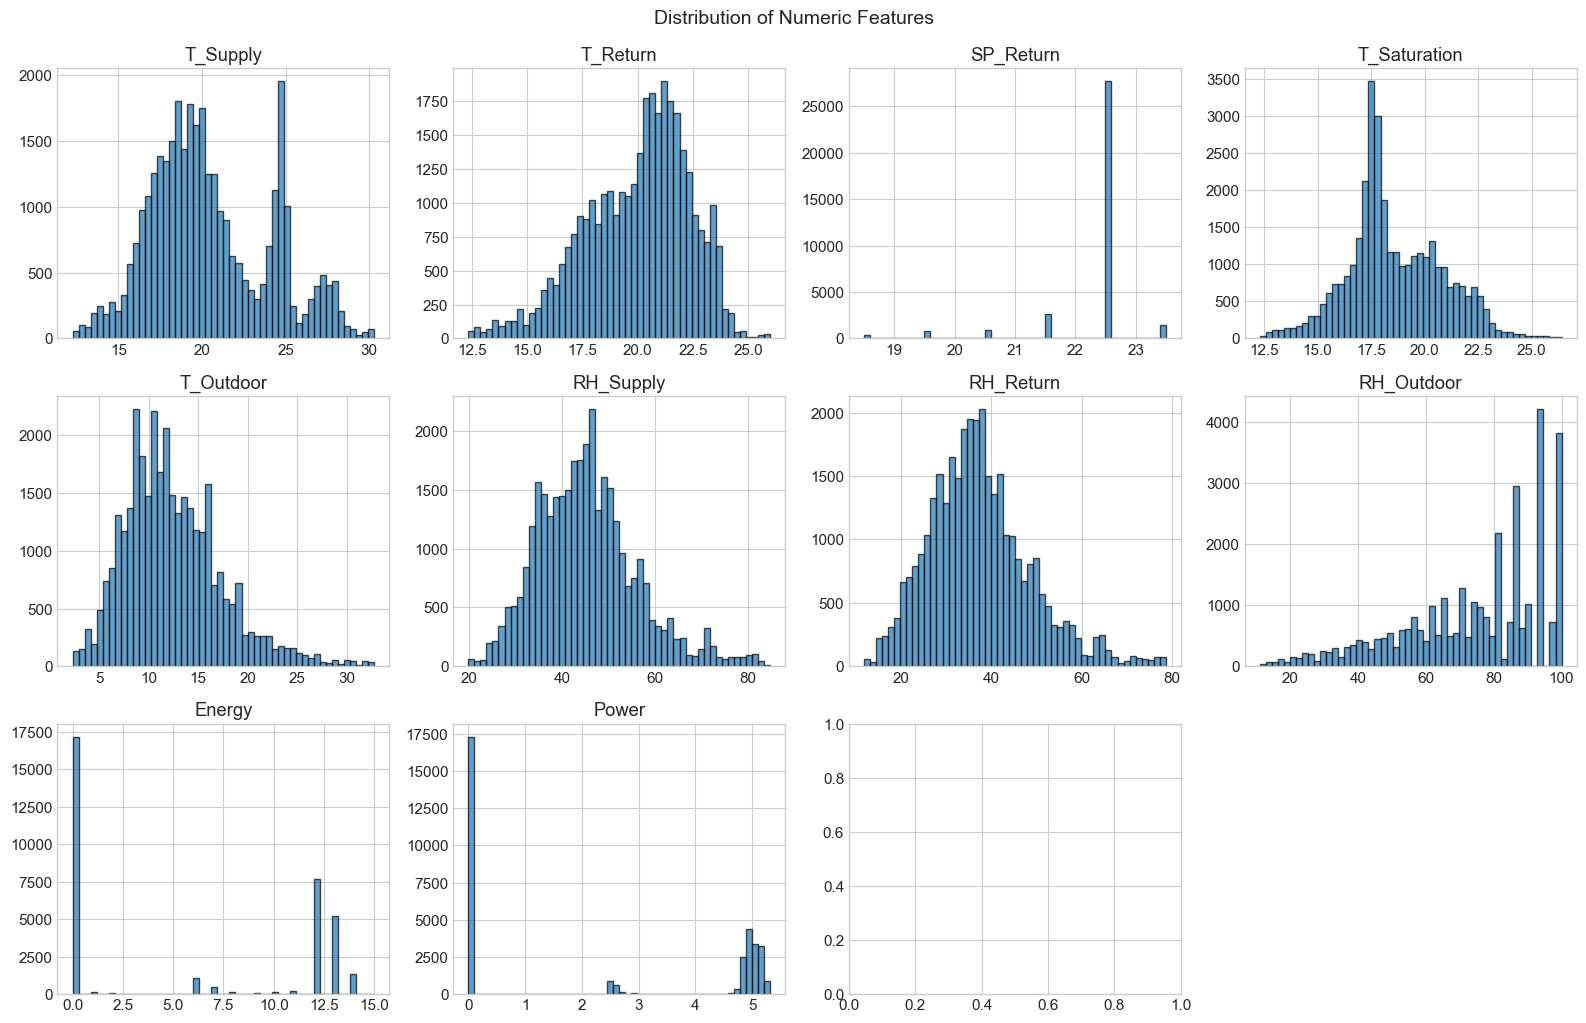

In [8]:
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols[:11]):
    axes[i].hist(df[col].dropna(), bins=50, edgecolor='black', alpha=0.7)
    axes[i].set_title(col)
    axes[i].set_xlabel('')

axes[-1].axis('off')
plt.tight_layout()
plt.suptitle('Distribution of Numeric Features', y=1.02, fontsize=14)
plt.show()

## 5. Temperature Analysis

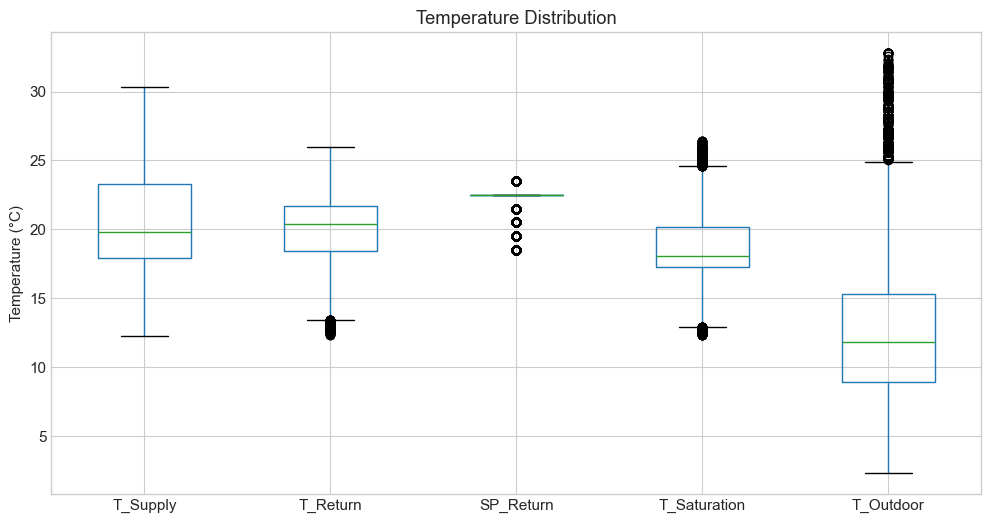

In [9]:
temp_cols = ['T_Supply', 'T_Return', 'SP_Return', 'T_Saturation', 'T_Outdoor']
fig, ax = plt.subplots(figsize=(12, 6))
df[temp_cols].boxplot(ax=ax)
ax.set_title('Temperature Distribution')
ax.set_ylabel('Temperature (°C)')
plt.show()

## 6. Humidity Analysis

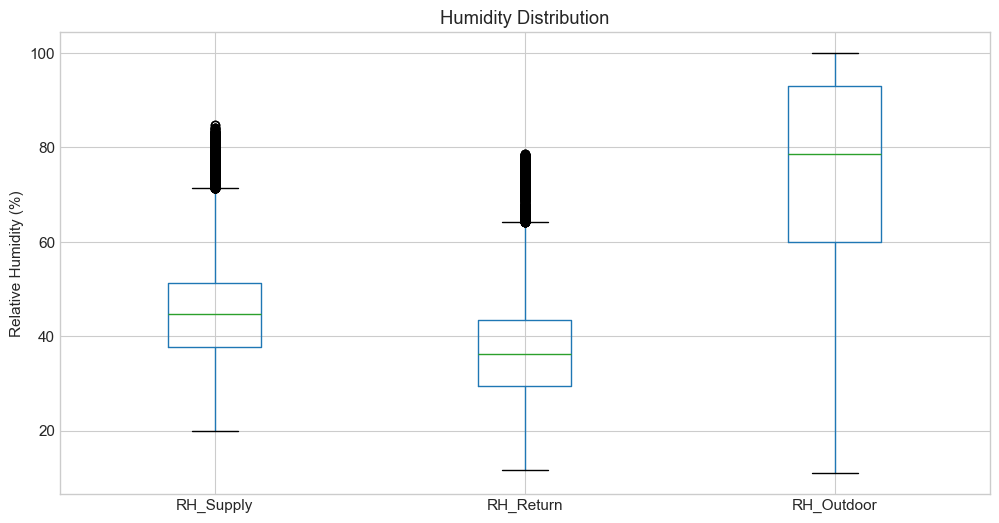

In [10]:
humidity_cols = ['RH_Supply', 'RH_Return', 'RH_Outdoor']
fig, ax = plt.subplots(figsize=(12, 6))
df[humidity_cols].boxplot(ax=ax)
ax.set_title('Humidity Distribution')
ax.set_ylabel('Relative Humidity (%)')
plt.show()

## 7. Energy & Power Analysis

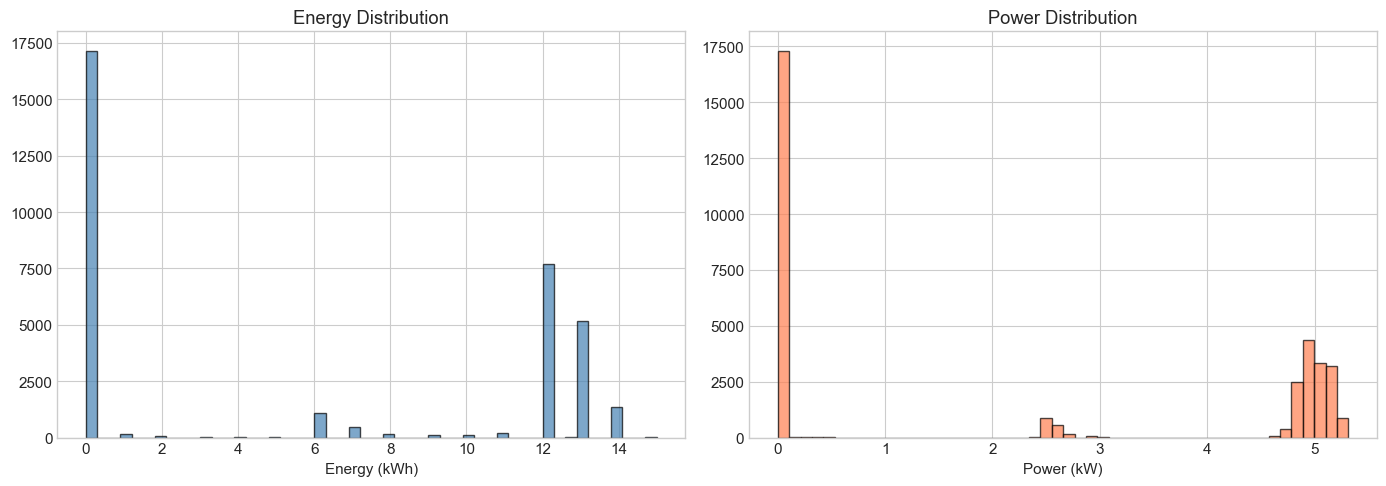

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['Energy'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].set_title('Energy Distribution')
axes[0].set_xlabel('Energy (kWh)')

axes[1].hist(df['Power'], bins=50, edgecolor='black', alpha=0.7, color='coral')
axes[1].set_title('Power Distribution')
axes[1].set_xlabel('Power (kW)')

plt.tight_layout()
plt.show()

## 8. Correlation Analysis

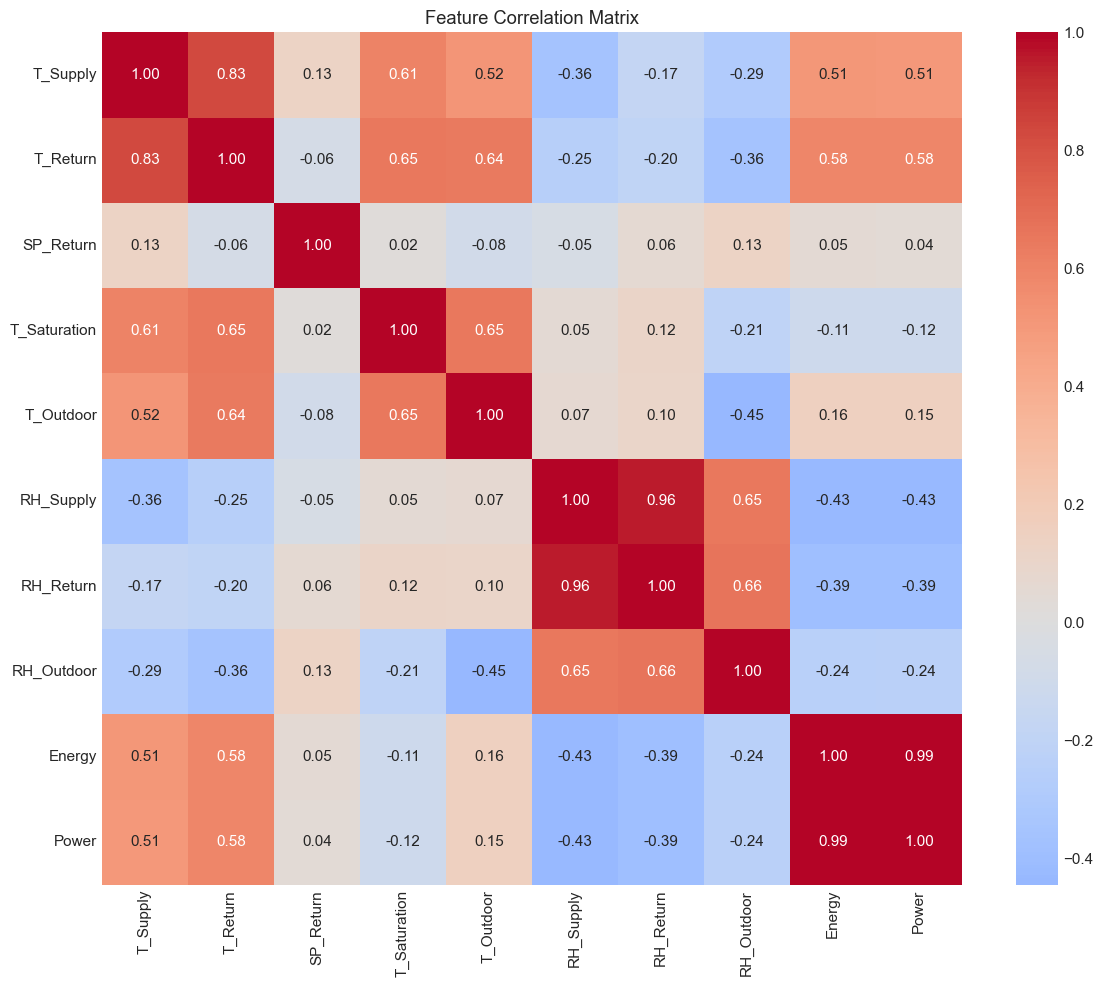

In [12]:
corr = df[numeric_cols[:11]].corr()
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

## 9. Time Series Analysis

In [13]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df = df.sort_values('Timestamp').reset_index(drop=True)
print(f"Date range: {df['Timestamp'].min()} to {df['Timestamp'].max()}")
print(f"Duration: {df['Timestamp'].max() - df['Timestamp'].min()}")

Date range: 2019-10-15 00:00:00+02:00 to 2021-04-14 23:45:00+02:00
Duration: 547 days 23:45:00


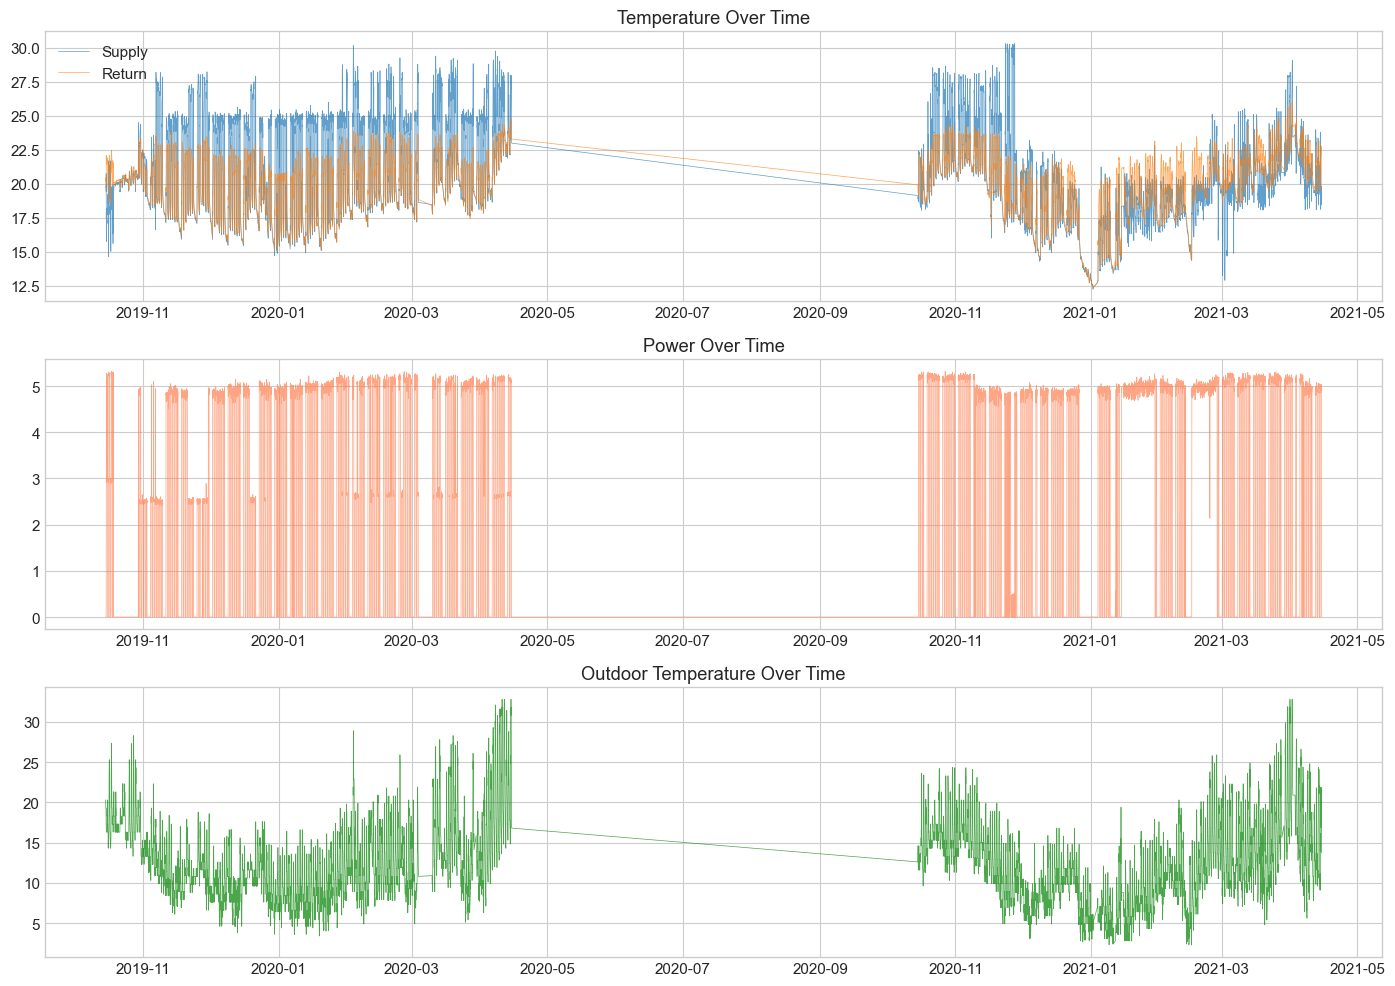

In [14]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

axes[0].plot(df['Timestamp'], df['T_Supply'], alpha=0.7, linewidth=0.5)
axes[0].plot(df['Timestamp'], df['T_Return'], alpha=0.7, linewidth=0.5)
axes[0].set_title('Temperature Over Time')
axes[0].legend(['Supply', 'Return'])

axes[1].plot(df['Timestamp'], df['Power'], alpha=0.7, linewidth=0.5, color='coral')
axes[1].set_title('Power Over Time')

axes[2].plot(df['Timestamp'], df['T_Outdoor'], alpha=0.7, linewidth=0.5, color='green')
axes[2].set_title('Outdoor Temperature Over Time')

plt.tight_layout()
plt.show()

## 10. Hourly Patterns

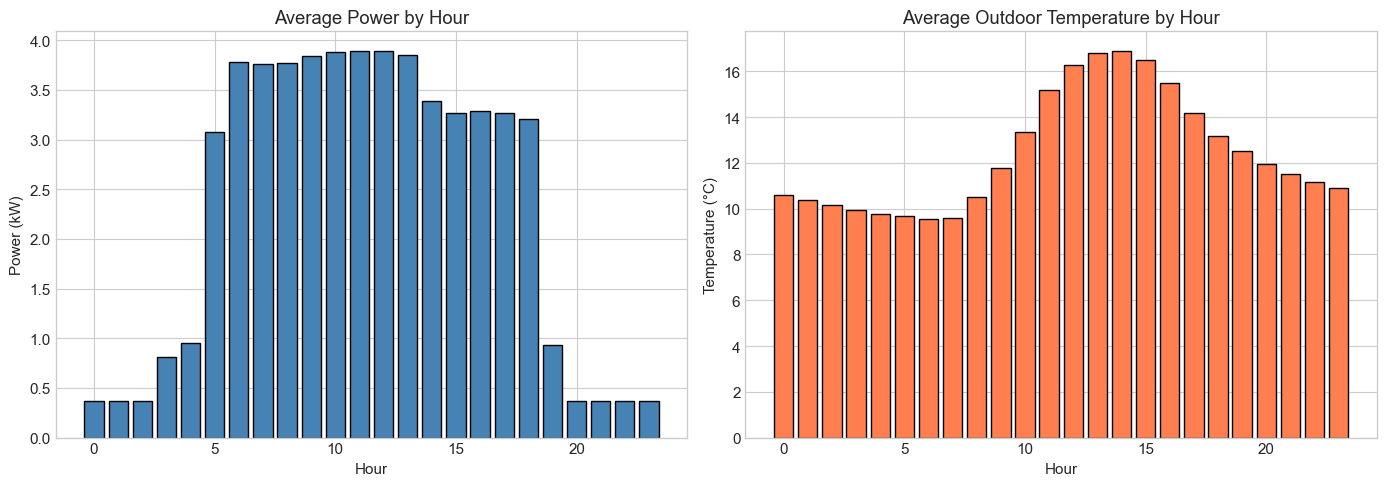

In [15]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'], utc=True)
df['Hour'] = df['Timestamp'].dt.hour
df['DayOfWeek'] = df['Timestamp'].dt.dayofweek

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

hourly_power = df.groupby('Hour')['Power'].mean()
axes[0].bar(hourly_power.index, hourly_power.values, color='steelblue', edgecolor='black')
axes[0].set_title('Average Power by Hour')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('Power (kW)')

hourly_temp = df.groupby('Hour')['T_Outdoor'].mean()
axes[1].bar(hourly_temp.index, hourly_temp.values, color='coral', edgecolor='black')
axes[1].set_title('Average Outdoor Temperature by Hour')
axes[1].set_xlabel('Hour')
axes[1].set_ylabel('Temperature (°C)')

plt.tight_layout()
plt.show()

## 11. Daily Patterns

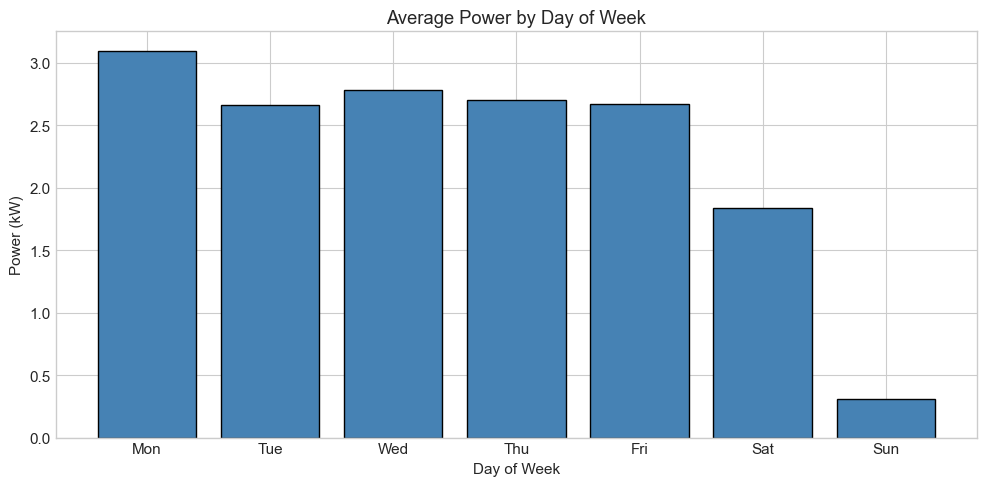

In [16]:
day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
daily_power = df.groupby('DayOfWeek')['Power'].mean()

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(day_names, daily_power.values, color='steelblue', edgecolor='black')
ax.set_title('Average Power by Day of Week')
ax.set_xlabel('Day of Week')
ax.set_ylabel('Power (kW)')
plt.tight_layout()
plt.show()

## 12. System On/Off Detection

System Duty Cycle: 48.55%


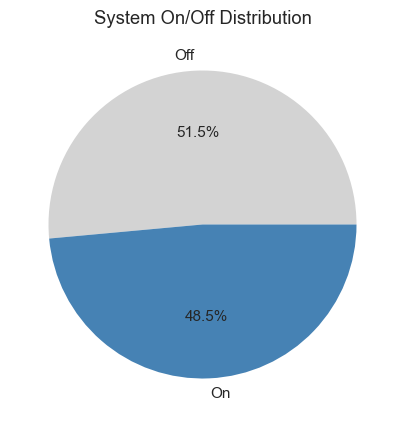

In [17]:
df['System_On'] = (df['Power'] > 0.5).astype(int)
duty_cycle = df['System_On'].mean() * 100
print(f"System Duty Cycle: {duty_cycle:.2f}%")

fig, ax = plt.subplots(figsize=(10, 5))
system_on_counts = df['System_On'].value_counts()
ax.pie(system_on_counts, labels=['Off', 'On'], autopct='%1.1f%%', colors=['lightgray', 'steelblue'])
ax.set_title('System On/Off Distribution')
plt.show()

## 13. Outlier Detection

In [18]:
def detect_outliers_iqr(df, column, threshold=1.5):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - threshold * IQR
    upper = Q3 + threshold * IQR
    outliers = df[(df[column] < lower) | (df[column] > upper)]
    return len(outliers), len(outliers) / len(df) * 100

print("Outliers (IQR method, threshold=1.5):")
print("-" * 50)
for col in numeric_cols[:11]:
    count, pct = detect_outliers_iqr(df, col)
    if count > 0:
        print(f"{col}: {count} ({pct:.2f}%)")

Outliers (IQR method, threshold=1.5):
--------------------------------------------------
T_Return: 257 (0.76%)
SP_Return: 6183 (18.25%)
T_Saturation: 347 (1.02%)
T_Outdoor: 689 (2.03%)
RH_Supply: 914 (2.70%)
RH_Return: 877 (2.59%)


## 14. Key Insights Summary

In [19]:
print("=" * 60)
print("KEY INSIGHTS SUMMARY")
print("=" * 60)
print(f"\n📊 Dataset:")
print(f"   - Total records: {len(df):,}")
print(f"   - Features: {len(df.columns)}")
print(f"   - Date range: {df['Timestamp'].min().date()} to {df['Timestamp'].max().date()}")

print(f"\n🌡️ Temperature:")
print(f"   - Supply: {df['T_Supply'].mean():.2f}°C (std: {df['T_Supply'].std():.2f})")
print(f"   - Return: {df['T_Return'].mean():.2f}°C (std: {df['T_Return'].std():.2f})")
print(f"   - Outdoor: {df['T_Outdoor'].mean():.2f}°C (std: {df['T_Outdoor'].std():.2f})")

print(f"\n⚡ Energy:")
print(f"   - Average Power: {df['Power'].mean():.2f} kW")
print(f"   - Max Power: {df['Power'].max():.2f} kW")
print(f"   - Total Energy: {df['Energy'].max():.2f} kWh")

print(f"\n🔄 System:")
print(f"   - Duty Cycle: {duty_cycle:.2f}%")
print(f"   - Peak Hours: 6 AM - 11 AM")

print("=" * 60)

KEY INSIGHTS SUMMARY

📊 Dataset:
   - Total records: 33,888
   - Features: 14
   - Date range: 2019-10-14 to 2021-04-14

🌡️ Temperature:
   - Supply: 20.44°C (std: 3.54)
   - Return: 19.99°C (std: 2.36)
   - Outdoor: 12.41°C (std: 4.93)

⚡ Energy:
   - Average Power: 2.31 kW
   - Max Power: 5.32 kW
   - Total Energy: 15.00 kWh

🔄 System:
   - Duty Cycle: 48.55%
   - Peak Hours: 6 AM - 11 AM
